In [1]:
# Copyright (c) 2025, Meredith Lochhead
# All rights reserved.
#
# This source code is licensed under the BSD 3-Clause License found in the
# LICENSE file in the root directory of this source tree.

In [2]:
# Relevant python functions
import pandas as pd
import numpy as np
import geopandas as gpd
import os
import sys
from pyproj import Transformer
from shapely.geometry import Point, box
import matplotlib.pyplot as plt
import folium
import contextily as ctx
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Import functions for inventory generation 
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
fxn_dir = os.path.join(parent_dir, "inventory_generation_functions")
sys.path.append(fxn_dir)

import functions_general as fxns
import functions_preprocessing as pre

In [3]:
# Set plotting CRS values for data manipulation and plotting
crs_main = '26910' # Used for data manipulation and storage
crs_plot = '4326' # Used for plotting 

# HAYWARD BOUNDS FOR PLOTTING 
xbounds = [-122.15, -122.02]
ybounds = [37.60, 37.69]

In [4]:
### DEFINE DIRECTORIES FOR ANALYSIS ###

## Create folder for preprocessed data 
directory = './Input_Data/ProcessedData/National/'
os.makedirs(directory, exist_ok=True)
dir_intermediate = directory + 'Intermediate/'
os.makedirs(dir_intermediate, exist_ok=True)

# Figure Directory 
fig_dir = './Figures/General/'
os.makedirs(fig_dir, exist_ok=True)

In [5]:
## Set flag to include CA School Database -- NOTE: Only set to true if using this code in Hayward
include_ca_school_data = False

## **Download NSI Data**

In [6]:
# # Set flag to download NSI data 
# download_nsi_data = False

# if download_nsi_data == True:
#     # Load City Boundary to define boudning box 
#     city_boundary = gpd.read_file('./Input_Data/Census/Census2010/Hayward_census.geojson')

#     # Convert to lat/long
#     city_boundary = city_boundary.to_crs(crs_plot)

#     # Download NSI data from API 
#     try: 
#         pre.download_nsi(city_boundary, crs_plot)
#     except: 
#         print('Error Downloading NSI Data')

## **Load and Preprocess Footprints and Boundaries**

In [7]:
# Select Footprint Source
footprint_path = './Input_Data/ProcessedFootprints/Hayward_Footprints.json'
footprints = gpd.read_file(footprint_path)
footprints.to_crs(crs_main, inplace = True)
footprints['FootprintID'] = footprints['FootprintID'].astype('Int64')

### DESCRIPTION ###
# Compute square footage to be used for "not full footprint" designation during merge process
# If most footprints have FootprintHeight available (in feet), set estimate_stories = True
# If most footprints do not have FootprintHeight available, using height to designate if 
# a footprint is not full may cause bias, and it is better to just use FootprintArea (set estimate_stories = False)

# Assign total square footage used for prioritizing attribution of points to footprints using "not full footprint"
estimate_stories = True
footprints = pre.estimate_ftpt_size_for_merge(footprints.copy(),estimate_stories)

In [8]:
# Load Census blocks and tracts (generated in preprocessing file)
hayward_blocks = gpd.read_file('./Input_Data/Census/Census2020/Hayward_blocks.geojson')
hayward_tracts = gpd.read_file('./Input_Data/Census/Census2020/Hayward_tracts.geojson')

## **Preprocess NSI Data**

444
651
JSON File Saved
For Hayward
34.479205169989996
31.002085735480005
65.48129090547


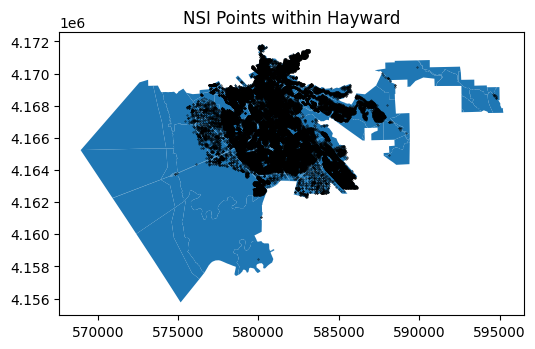

In [9]:
##### LOAD NSI DATA DOWNLOADED USING BRAILS TOOL AND CONVERT TO APPROPRIATE CRS #####
nsi = gpd.read_file('./Input_Data/National/nsi_01_29_2026/06001.gpkg')
nsi = nsi.to_crs(epsg=crs_main)


# ##### RENAME AND DROP NSI COLUMNS AS APPROPRIATE #####
# # Note - if different columns present in the nsi dataframe than in the case of Hayward, go to the 
# # rename_nsi_data function and comment out / add appropriate column names as needed 
# nsi = pre.rename_nsi_data(nsi.copy())


# Drop unnecessary columns from NSI data
nsi.drop(['USASTRUCID','ST_DAMCAT', 'FTPRNTID', 'BSMNT', 'VEHPERUNIT', 'PCTLOWCLR','VAL_VEHIC','CENSREGION','POP_CI95_L','POP_MEDIAN',
       'POP_CI95_U', 'FLD_ZONE', 'ZONE_SUBTY', 'STATIC_BFE','NOVEHPROB','U65DISABLE','O65DISABLE','DEPRECIATN','HEIGHT', 'X', 'Y'], # SVI
                    axis=1, inplace=True)

# Rename columns to more meaningful names
nsi = nsi.rename(columns={
    'FNDTYPE': 'NSI_FoundationType',
    'FOUND_HT': 'NSI_FoundationHeight',
    'EXTWALL': 'NSI_BuildingType',
    'MED_YR_BLT': 'NSI_MedYearBuilt',
    'CBFIPS2020': 'CensusBlock',
    'OCCTYPE': 'NSI_OccupancyClass',
    'NUM_STORY': 'NSI_NumberOfStories',
    'SOURCE': 'NSI_OrigSource',
    'FTPRNTSRC': 'NSI_OrigFtptSource',
    'BID': 'NSI_BID',
    'SQFT': 'NSI_TotalAreaSqFt',
    'RESUNITS': 'NSI_Units',
    'POP2AMU65': 'NSI_PopUnder65_Night',
    'POP2AMO65': 'NSI_PopOver65_Night',
    'POP2PMU65': 'NSI_PopUnder65_Day',
    'POP2PMO65': 'NSI_PopOver65_Day',
    'VAL_CONT': 'NSI_ContentValue',
    'VAL_STRUCT': 'NSI_StructureValue',
    'STUDENTS': 'NSI_Students',
    'REPLCVALUE': 'NSI_ReplacementCost'})
nsi['NSI_Population_Night'] = nsi[['NSI_PopUnder65_Night', 'NSI_PopOver65_Night']].sum(axis=1)
nsi['NSI_Population_Day'] = nsi[['NSI_PopUnder65_Day', 'NSI_PopOver65_Day']].sum(axis=1)


# For consistency with 2022, set replacement cost as sum of structure value and content value 
print(round(nsi['NSI_ReplacementCost'].sum()/10**9))
nsi = nsi.drop(columns='NSI_ReplacementCost')
nsi['NSI_ReplacementCost'] = nsi[['NSI_ContentValue', 'NSI_StructureValue']].sum(axis=1)
print(round(nsi['NSI_ReplacementCost'].sum()/10**9))

# Make proxy for fdid
nsi['NSI_fdid'] = np.arange(len(nsi))


# # Merge NSI data with City-Specific Census Blocks and check for errors in NSI data
# nsi = pre.assign_point_block_and_track(nsi, hayward_blocks, hayward_tracts)
nsi = nsi[nsi['CensusBlock'].isin(hayward_blocks['GEOID20'].to_list())].copy()

## Merge Census Tract 
nsi = nsi.sjoin(hayward_tracts[['GEOID20','geometry']], how='left', predicate='within')
nsi = nsi.rename(columns={'GEOID20':'CensusTract'})
nsi = nsi.drop(columns = ['index_right'])

# Standardize RES1 occupancy Types for consistency with other inventories
nsi['NSI_OccupancyClass'] = nsi['NSI_OccupancyClass'].apply(lambda x: 'RES1' if 'RES1' in str(x) else x)


#
# Plot Results
fig, ax = plt.subplots(1,1, figsize = (6, 6))
hayward_blocks.plot(ax=ax)
nsi.plot(ax=ax, color ='black', markersize = 0.1)
ax.set_title('NSI Points within Hayward')


##### CREATE ADDITIONAL COLUMNS TO BE USED IN FOOTPRINT MERGE #####
nsi['NSI_OC_Update'] = None # This will contain updated Occupancy Class values throughout merge
nsi['POINT_DropFlag'] = 0 # This indicates whether a row should be dropped from the final inventory. 1 indicates yes, 0 indicates no 
nsi['POINT_DropNote'] = "" # Space for notes on the reason data points are dropped 
nsi['POINT_Source'] = 'NSI' # This tracks the original data source for each row 
nsi['POINT_DataUpdate'] = "" # Space for notes on steps throughout update 

# Save inventory
fxns.gdf_to_json(nsi, dir_intermediate + 'Hayward_NSI.json')

print('For Hayward')
print((nsi['NSI_StructureValue'].sum()/10**9))
print((nsi['NSI_ContentValue'].sum()/10**9))
print((nsi['NSI_ReplacementCost'].sum()/10**9))

In [10]:
#  NOTE: Hazus 6.1 Inventory removes all AGR1 points with no square footage and/or footprint associated due to overesimation in some areas. 
# None of those points were found in Hayward, so this is not included here 

## **Augment NSI Data using HIFLD Data**

Based on experimentation in Hayward, CA, the existing NSI data has some missing or incorrectly assigned information related to EDU and GOV occupancy types. This section uses imported HIFLD data to augment the existing NSI data

Data Downloaded Here: 
https://experience.arcgis.com/experience/2dedf7da18254d75b562cc51ba3a1653

### **Update EDU1 Points**


 NSI Data in Hayward seemed to be missing a significant amount of school points (or they were labeled as GOV1 instead of EDU). This section aims to address that inconsistenty in the data. 
 


Public Schools: 38
Private Schools: 13


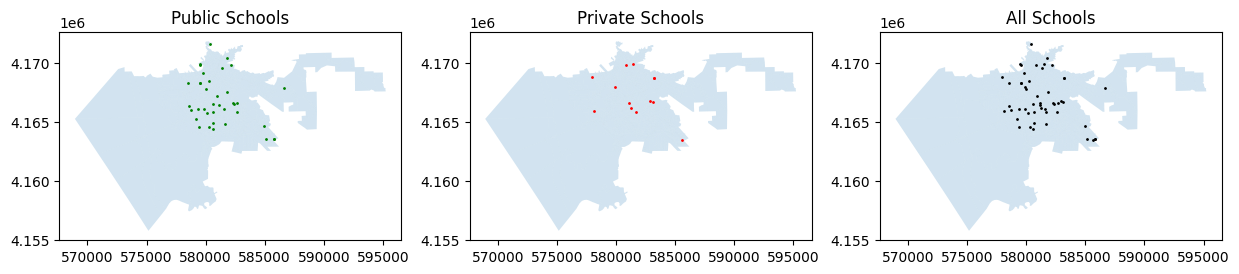

In [11]:
##### FIRST, ADDRESS EDU1 POINTS, WHICH CONSIST OF K-12 SCHOOLS #####

##### LOAD IMPORTED EDUCATIONAL HIFLD DATA AND CONVERT COORDINATES #####
public = gpd.read_file('./Input_Data/HIFLD/Public_Schools.geojson')
private = gpd.read_file('./Input_Data/HIFLD/Private_Schools.geojson')
public = public.to_crs(epsg=crs_main)
private = private.to_crs(epsg=crs_main)



##### MANUALLY REASSIGN SCHOOLS THAT WERE INCOREECTLY LOCATED - did this manually for one case in Hayward  #####
# Ruus Elementary School 
transformer = Transformer.from_crs("EPSG:4326", f"EPSG:{crs_main}")
new_point = Point(transformer.transform(37.62699979615092,-122.07455518939621)) # Manually taken from Google Maps
row_index = public[public['NAME'].str.contains('RUUS')].index[0]
public.at[row_index, 'geometry'] = new_point




##### SORT FOR SCHOOLS WITHIN HAYWARD AND ASSIGN CENSUS TRACT AND BLOCK INFOMRATION #####

# Assign blocks and clean data
public_hayward, private_hayward, school_import = pre.format_and_locate_edu1(public, private, hayward_tracts, hayward_blocks, 'GEOID20')

##### PLOT RESULTS #####
fig, ax = plt.subplots(1,3, figsize = (15, 12))
hayward_blocks.plot(ax=ax[0], alpha = 0.2)
public_hayward.plot(ax=ax[0], color ='green', markersize = 1)
ax[0].set_title('Public Schools')
hayward_blocks.plot(ax=ax[1], alpha = 0.2)
private_hayward.plot(ax=ax[1], color ='red', markersize = 1)
ax[1].set_title('Private Schools')
hayward_blocks.plot(ax=ax[2], alpha = 0.2)
school_import.plot(ax=ax[2], color ='black', markersize = 1)
ax[2].set_title('All Schools')
plt.show()

In [12]:
# #### IMPORT SCHOOL DATA FROM CALIFORNIA DATABSE TO AUGMENT YEAR BUILT ####

if include_ca_school_data: 

    ## NOTE: This is only relevant for Hayward -- do NOT run this cell if you are running a general case study 

    # Load schools 
    schools = pd.read_excel('./Input_Data/Local/CDESchoolDirectoryExport.xlsx', skiprows=5, header=0)

    # Filter for Hayward schools 
    schools = schools[schools['Street City']=='Hayward']

    # Convert to geodataframe
    schools['Latitude'] = pd.to_numeric(schools['Latitude'])
    schools['Longitude'] = pd.to_numeric(schools['Longitude'])
    schools['geometry'] = schools.apply(lambda row: Point(row['Longitude'], row['Latitude']), axis=1)
    gdf_schools = gpd.GeoDataFrame(schools, geometry='geometry')
    gdf_schools.set_crs(epsg=crs_main, inplace=True)
    schools = gdf_schools[['School', 'Open Date']].copy()

    # Extract school Open Date and remove instances of 1980 (appears to be a placeholder date)
    schools['NSI_MedYearBuilt'] = schools['Open Date'].dt.year
    schools.loc[schools['NSI_MedYearBuilt'] == 1980, 'NSI_MedYearBuilt'] = np.nan

    # Rename some shcools to match HIFLD data
    schools.loc[schools['School'] == 'Bayside Seventh-day Adventist Christian', 'School'] = 'BAYSIDE ADVENTIST CHRISTIAN SCHOOL'
    schools.loc[schools['School'] == 'Martin Luther King, Jr. Middle', 'School'] = 'MARTIN LUTHER KING JR. MIDDLE'
    schools.loc[schools['School'] == 'Saint Clement Catholic School', 'School'] = 'ST CLEMENT CATHOLIC SCHOOL'
    schools.loc[schools['School'] == 'St. Bede School', 'School'] = 'ST BEDE CATHOLIC SCHOOL'
    schools.loc[schools['School'] == "St. Joachim's Elementary", 'School'] = 'ST JOACHIM SCHOOL'


    #### Merge imported CA school data and HIFLD data ####

    # Ensure case-insensitive matching by converting to lowercase
    schools['col1_lower'] = schools['School'].str.lower()
    school_import['col1_lower'] = school_import['NAME'].str.lower()


    # Perform the merge
    merged_df = pd.merge(
        schools[['col1_lower', 'NSI_MedYearBuilt']],
        school_import,
        on='col1_lower',
        how='right'
    )

    # Convert to GeoDataFrame, using the geometry from school_import
    merged_gdf = gpd.GeoDataFrame(merged_df, geometry=school_import.geometry, crs=school_import.crs)

    # Drop extra columns and rename
    school_import = merged_gdf.drop(columns=['col1_lower','NAME'])

else: 
    # Drop NAME (Used only for above mapping to CA database)
    school_import = school_import.drop(columns=['NAME'])


In [13]:
# ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND NSI POINTS

# # Create a base map
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(footprints.copy().to_crs(crs_plot), color = 'gray').add_to(m)

# # Add remaining points     
# for idx, row in nsi[nsi['NSI_OccupancyClass']=='EDU1'].copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=4, 
#                         color='red', 
#                         fill=True, 
#                         fill_color='red', 
#                         popup=row['NSI_OccupancyClass']).add_to(m)
    
# # Add remaining points     
# for idx, row in school_import.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=4, 
#                         color='blue', 
#                         fill=True, 
#                         fill_color='blue').add_to(m)

# display(m)

In [14]:
# ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND NSI POINTS

# # Create a base map
# m = folium.Map(location=[hayward_blocks.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, hayward_blocks.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(footprints.copy().to_crs(crs_plot), color = 'gray').add_to(m)

# # Add remaining points     
# for idx, row in nsi[nsi['NSI_OccupancyClass']=='GOV1'].copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='red', 
#                         fill=True, 
#                         fill_color='red', 
#                         popup=row['NSI_OccupancyClass']).add_to(m)
    
# # Add remaining points     
# for idx, row in school_import.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=4, 
#                         color='blue', 
#                         fill=True, 
#                         fill_color='blue').add_to(m)

# display(m)

In [15]:
# ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND NSI POINTS
# ##### LOAD NSI DATA #####
# nsi = fxns.json_to_gdf(dir_intermediate + 'Hayward_NSI.json', crs_main)
# subset = nsi[nsi['POINT_DropFlag']==0]


# # Create a base map
# m = folium.Map(location=[hayward_blocks.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, hayward_blocks.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(footprints.copy().to_crs(crs_plot), color = 'gray').add_to(m)

# # Add remaining points     
# for idx, row in nsi[nsi['NSI_OccupancyClass']=='GOV1'].copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='red', 
#                         fill=True, 
#                         fill_color='red', 
#                         popup=row['NSI_OccupancyClass']).add_to(m)
    

# for idx, row in nsi[nsi['NSI_OccupancyClass'].str.contains('EDU1')].copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='black', 
#                         fill=True, 
#                         fill_color='black', 
#                         popup=row['NSI_OccupancyClass']).add_to(m)
    

# # Add remaining points     
# for idx, row in school_import.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=4, 
#                         color='blue', 
#                         fill=True, 
#                         fill_color='blue').add_to(m)

# display(m)

In [16]:
##### LOAD NSI DATA #####
nsi = fxns.json_to_gdf(dir_intermediate + 'Hayward_NSI.json', crs_main)

# Synthesize NSI EDU1 data that is within a 50m radius of a HIFLD EDU point, drop all other NSI EDU1 points 
# Set flag to true to display HIFLD and NSI EDU Points
drop_unpaired_nsi_edu1 = False # Flag to drop all NSI points, other than those closest to HIFLD school points (max 50 m)
drop_edu1_far_from_hifld = True # Flag to drop all NSI EDU1 points farther than 150m from NSI 
gov1_near_edu1 = 'convert' # options: drop, convert (converts to EDU1), or keep 

nsi = pre.synthesize_edu1_and_HIFLD_nsi26_update(nsi, school_import, drop_unpaired_nsi_edu1, drop_edu1_far_from_hifld, gov1_near_edu1)

# Save updated NSI dataframe 
fxns.gdf_to_json(nsi, dir_intermediate + 'NSI_EDU1_Upgrade.json')

/Users/mialochhead/Documents/GitHub/Building_Inventory_Generation/inventory_generation_functions/functions_preprocessing.py:845: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'EDU1' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  nsi.loc[gov1_near_edu1.index,'NSI_OC_Update']='EDU1'


JSON File Saved


### **Update EDU2 Points**


 NSI Data in Hayward seemed to be missing information related to colleges and universities (EDU2 points) including the location of campuses, points incorrectly designated as GOV1, and incorrect population information (i.e. Hayward had no GOV2 points available at all.) This section aims to address that inconsistenty in the data. 


Campus Polygons: 3
College/Univeristy Points: 4


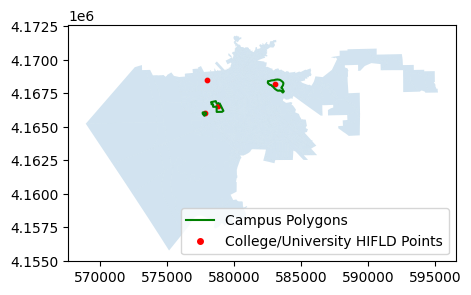

In [17]:
##### ADDRESS EDU2 POINTS, WHICH CONSIST OF COLLEGES/UNIVERSITIES #####

##### LOAD IMPORTED COLLEGE/UNIVERSITY HIFLD DATA AND CONVERT COORDINATES #####
univ = gpd.read_file('./Input_Data/HIFLD/Colleges_and_Universities_Campuses.geojson')
univ_pts = gpd.read_file('./Input_Data/HIFLD/Colleges_and_Universities.geojson')
univ = univ.to_crs(epsg=crs_main)
univ_pts = univ_pts.to_crs(epsg=crs_main)


##### SORT FOR SCHOOLS WITHIN HAYWARD AND ASSIGN CENSUS TRACT AND BLOCK INFOMRATION #####

# Assign blocks and clean data
univ_hayward, univ_pts_hayward = pre.locate_edu2(univ, univ_pts, hayward_tracts, hayward_blocks, 'GEOID20')


##### PLOT HIFLD DATA #####
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
hayward_blocks.plot(ax=ax, alpha=0.2)
univ_hayward.boundary.plot(ax=ax, color='green') 
univ_pts_hayward.plot(ax=ax, color='red', markersize=10)
univ_hayward_line = mlines.Line2D([], [], color='green', label='Campus Polygons')
univ_pts_hayward_point = mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=4, label='College/University HIFLD Points')
ax.legend(handles=[univ_hayward_line, univ_pts_hayward_point], loc='lower right')
plt.show()


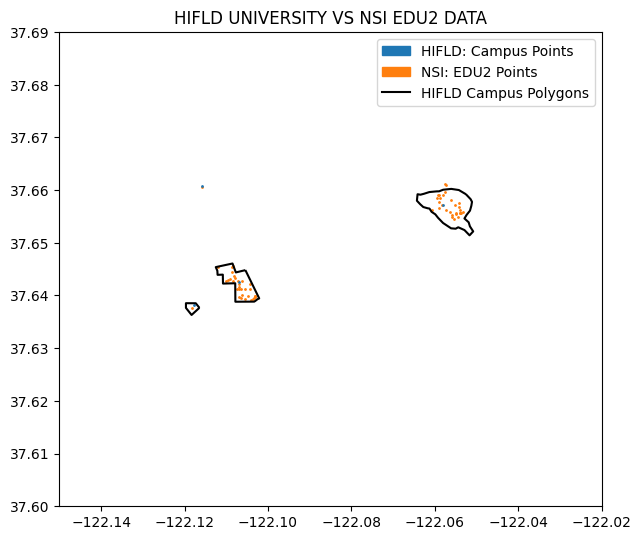

In [18]:
##### PLOT HIFLD EDU2 VS NSI EDU2 -- THIS CELL ONLY PLOTS DATA #####

nsi = fxns.json_to_gdf(dir_intermediate + 'Hayward_NSI.json', crs_main)
edu2 = nsi[nsi['NSI_OccupancyClass'] == 'EDU2']

##### DISPLAY SCHOOL POINTS #####
fig, ax = plt.subplots(figsize = (7,7))

if len(edu2) > 0: 
    edu2.copy().to_crs(crs_plot).plot(ax=ax, color = 'tab:orange', markersize=1) # MTL CHANGE NSI26 - should be changed in other 
else: 
    print('No EDU2 points in NSI data')

univ_pts_hayward.copy().to_crs(crs_plot).plot(ax=ax, color = 'tab:blue',  markersize=1)
univ_hayward.copy().to_crs(crs_plot).boundary.plot(ax=ax, color='black') 

# Bounds
plt.xlim(xbounds)
plt.ylim(ybounds)

# Add the OpenStreetMap basemap
# ctx.add_basemap(ax, crs='EPSG:4269', source=ctx.providers.CartoDB.VoyagerNoLabels)

handles = [
    mpatches.Patch(color='tab:blue', label='HIFLD: Campus Points'),
    mpatches.Patch(color='tab:orange', label='NSI: EDU2 Points'),
    mlines.Line2D([], [], color='black', label='HIFLD Campus Polygons')
]
ax.legend(handles=handles)

# Show the plot
plt.title('HIFLD UNIVERSITY VS NSI EDU2 DATA')
plt.show()

In [19]:
##### MERGE CAMPUS HIFLD DATA INTO NSI DATAFRAME 
# Load NSI Data 
nsi = fxns.json_to_gdf(dir_intermediate + 'NSI_EDU1_Upgrade.json', crs_main)

##### POINTS WITHOUT CAMPUS POLYGONS #####
# Find points without associated campus polygons and append them in NSI data
edu2_no_campus = pre.prepare_pts_without_campuses(univ_pts_hayward, univ_hayward, nsi.copy())
nsi = pd.concat([nsi,edu2_no_campus])

# ##### POINTS WITH CAMPUS POLYGONS, BUT WITHOUT GOV1 POINTS INSIDE #####
# # Find points and append them in NSI data
edu2_no_gov1 = pre.prepare_pts_without_gov1_nsi26_update(univ_pts_hayward, univ_hayward, nsi.copy())
nsi = pd.concat([nsi,edu2_no_gov1])

##### POINTS WITH CAMPUS POLYGONS, WITH GOV1 POINTS INSIDE #####
# Find GOV1 points within campus polygons and reassign them as EDU2

# Set flag to determine if NSI population should be scaled within campus polygons to match HIFLD campus enrollment 
scale_edu2_pop = True
nsi = pre.merge_pts_with_campuses_nsi26_update(univ_hayward, nsi.copy(), scale_edu2_pop)

##### SAVE NSI #####
fxns.gdf_to_json(nsi, dir_intermediate + 'NSI_EDU1_EDU2_Upgrade.json')

JSON File Saved


In [20]:
##### RUN CHECK: FOLLOWING NUMBERS SHOULD MATCH (WITHIN SCALING/ROUNDINGß ERROR) #####
for school_num in range(len(univ_hayward)):
    one_univ = univ_hayward.iloc[[school_num]]
    one_univ_convert = nsi.sjoin(one_univ[['UNIQUEID','POPULATION','TOT_ENROLL','TOT_EMP','geometry']], how='inner')
    print('\nNSI Day',sum(one_univ_convert['NSI_Population_Day']))
    print('Imported School Population',one_univ['POPULATION'].values)


NSI Day 18017.0
Imported School Population [18010]

NSI Day 12638.0
Imported School Population [12626]

NSI Day 786.0
Imported School Population [786]


### **Update GOV2 Points**


 NSI Data in Hayward seemed to be missing information related to emergency response including the location of fire stations, police stations, and emergency options centers. These points may be present in NSI and mislabeled as GOV1. This section aims to address that inconsistently in the data. 

In [21]:
##### ADDRESS GOV2 POINTS, WHICH CONSIST OF EMERGENCY RESPONSE BUILDINGS #####

##### LOAD IMPORTED HIFLD DATA, CONVERT COORDINATES, AND ASSIGN CENSUS #####
fire = gpd.read_file('./Input_Data/HIFLD/Fire_and_Emergency_Medical_Service_(EMS)_Stations.geojson')
police = gpd.read_file('./Input_Data/HIFLD/Local_Law_Enforcement_Locations.geojson')
local_eoc = gpd.read_file('./Input_Data/HIFLD/Local_Emergency_Operations_Centers_EOC.geojson')
state_eoc = gpd.read_file('./Input_Data/HIFLD/State_Emergency_Operations_Centers_EOC.geojson')

# Convert Coordinates
fire = fire.to_crs(epsg=crs_main)
police = police.to_crs(epsg=crs_main)
local_eoc = local_eoc.to_crs(epsg=crs_main)
state_eoc = state_eoc.to_crs(epsg=crs_main)

# Assign Census Block and Tract to HIFLD Data
fire = pre.assign_census_hifld(fire, hayward_blocks, hayward_tracts, 'GEOID20') # MTL CHANGE NSI26 new input
police = pre.assign_census_hifld(police, hayward_blocks, hayward_tracts, 'GEOID20') # MTL CHANGE NSI26 new input
local_eoc = pre.assign_census_hifld(local_eoc, hayward_blocks, hayward_tracts, 'GEOID20') # MTL CHANGE NSI26 new input
state_eoc = pre.assign_census_hifld(state_eoc, hayward_blocks, hayward_tracts, 'GEOID20') # MTL CHANGE NSI26 new input


##### MERGE DATA FOR FUTURE USE #####

# Reduce columns and set class
fire = fire[['geometry', 'CensusBlock', 'CensusTract']]
fire['NSI_OccupancyClass'] = "GOV2-FIRE"
police = police[['geometry', 'CensusBlock', 'CensusTract']]
police['NSI_OccupancyClass'] = "GOV2-POLICE"
local_eoc = local_eoc[['geometry', 'CensusBlock', 'CensusTract']]
local_eoc['NSI_OccupancyClass'] = "GOV2-OPERATIONS"
state_eoc = state_eoc[['geometry', 'CensusBlock', 'CensusTract']]
state_eoc['NSI_OccupancyClass'] = "GOV2-OPERATIONS"

# Concatinate and prepare for merge
gov2_import = pd.concat([fire, police, local_eoc, state_eoc], ignore_index=True, sort=False)


##### SYNTHESIZE NSI GOV2 AND HIFLD POINTS #####
nsi = fxns.json_to_gdf(dir_intermediate + 'NSI_EDU1_EDU2_Upgrade.json', crs_main)

# Set flag to true to display HIFLD and NSI GOV2 Points
drop_unpaired_nsi_gov2 = False # Flag to drop all NSI points, other than those closest to HIFLD GOV2 points (max 50 m)
gov2_far_from_hifld = 'convert'  # options: drop, convert (converts to GOV1), or keep 
drop_gov1_near_gov2 = False # Flag to drop all NSI GOV1 points within 10m

nsi = pre.synthesize_gov2_and_HIFLD_nsi26_update(nsi, gov2_import, drop_unpaired_nsi_gov2, drop_gov1_near_gov2, gov2_far_from_hifld)

##### SAVE NSI #####
fxns.gdf_to_json(nsi, dir_intermediate + 'NSI_EDU1_EDU2_GOV2_Upgrade.json')

JSON File Saved


In [22]:
# ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND NSI POINTS

# # Create a base map
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(footprints.copy().to_crs(crs_plot), color = 'gray').add_to(m)

# # Add remaining points     
# for idx, row in nsi[nsi['NSI_OccupancyClass']=='GOV2'].copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=6, 
#                         color='red', 
#                         fill=True, 
#                         fill_color='red', 
#                         popup=row['NSI_OccupancyClass']).add_to(m)
    
# # Add remaining points     
# for idx, row in gov2_import.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=3, 
#                         color='blue', 
#                         fill=True, 
#                         fill_color='blue').add_to(m)

# display(m)

## **Establish Variables and Merge Duplicate BIDs**

In [23]:
#### LOAD IN UPDATED NSI DATA #####
nsi = fxns.json_to_gdf(dir_intermediate + 'NSI_EDU1_EDU2_GOV2_Upgrade.json', crs_main)

#### CREATE ID AND SET COLUMNS #####

filter_limit = 450  # sqft limit below which to filter small NSI points
nsi = pre.add_nsi_tracking_columns(nsi, filter_limit)

### COMPUTE MIN AND MAX OF RANGE OF RES UNITS BASED ON OCCUPANCY CLASS ### 
nsi = pre.compute_min_mix_units(nsi)


In [24]:
### DEFINE COLUMNS TO BE SUMMED OR COVERTED TO LISTS WHEN COMBINED ### 
# sum_columns get summed when points are merged (i.e. replacement cost)
# list_columns get put into lists (if information differs) when points are merged (i.e. foundation type)

# Set category of certain column names
excluded = ['geometry', 'CensusBlock', 'CensusTract', 'POINT_ID', 'NSI_OccupancyClass', 'POINT_DropFlag', 'POINT_DropNote', 'NSI_OC_Update',
            'POINT_FootprintID', 'DistanceToFtpt', 'ClosestFtpt_ID', 'POINT_MergeFlag','POINT_DataUpdate']
sum_columns = ['NSI_PopOver65_Day', 'NSI_PopUnder65_Day', 'NSI_Population_Day',
                    'NSI_PopOver65_Night', 'NSI_PopUnder65_Night', 'NSI_Population_Night','NSI_ContentValue','NSI_ReplacementCost',
                    'NSI_StructureValue','NSI_MinResUnits', 'NSI_MaxResUnits','POINT_NumPoints','NSI_Units','NSI_Students']
list_columns = ['NSI_FoundationType','NSI_FoundationHeight','NSI_BuildingType','NSI_MedYearBuilt',
                'NSI_NumberOfStories', 'POINT_Source', 'NSI_OrigSource', 'NSI_OrigFtptSource','NSI_BID','POINT_ID_List','NSI_TotalAreaSqFt']

# Check that all columns are assigned to a category
fxns.check_column_assignment(nsi, sum_columns, list_columns, excluded)

    

No Unassigned Columns


In [25]:
##### Group NSI rows with same BID ####

##### SPLIT DATA BASED ON DROP_FLAG #####
nsi_length = len(nsi) # Used for tracking purposes 
nsi0 = nsi[nsi['POINT_DropFlag']!=1] # Not dropped - these should be used in merge
nsi1 = nsi[nsi['POINT_DropFlag']==1] # Dropped - these should not be used in merge 

# Assuming values with same BID are all intended to be in the same footprint moving forward 
nsi0 = pre.merge_duplicate_bid(nsi0, list_columns, sum_columns)  

##### REUNITE DATA BASED ON DROP_FLAG AND CHECK THAT ALL POINTS WERE RETAINED #####
nsi = pre.recombine_dropped_data(nsi0, nsi1, nsi_length)

##### SAVE NSI #####
if include_ca_school_data: 
    fxns.gdf_to_json(nsi, directory + 'NSI_for_Merge_with_CA_Data.json')
else: 
    fxns.gdf_to_json(nsi, directory + 'NSI_for_Merge.json')

JSON File Saved


In [26]:

# print('For Hayward')
# print((nsi[nsi['POINT_DropFlag']==0]['NSI_StructureValue'].sum()/10**9))
# print((nsi[nsi['POINT_DropFlag']==0]['NSI_ContentValue'].sum()/10**9))
# print((nsi[nsi['POINT_DropFlag']==0]['NSI_ReplacementCost'].sum()/10**9))